In [3]:
# STEP 1: Install Required Libraries
!pip install -q transformers torchvision datasets accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.5 MB/s eta 0:00:00


In [4]:
# STEP 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import zipfile
import os

# Replace this with the actual path to your zip file in Drive
zip_path = '/content/drive/MyDrive/Brain-Stroke-CT-DatasetSplit.zip'
extract_path = '/content/brain_ct_dataset'

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset unzipped.")


 Dataset unzipped.


In [19]:
for root, dirs, files in os.walk(extract_path):
    print(f"\n {root}")
    for d in dirs:
        print(f"    {d}")
    for f in files[:5]:
        print(f"    {f}")



 /content/brain_ct_dataset
    __MACOSX
    Brain-Stroke-CT-DatasetSplit

 /content/brain_ct_dataset/__MACOSX
    Brain-Stroke-CT-DatasetSplit
    ._Brain-Stroke-CT-DatasetSplit

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit
    train
    test
    ._test
    ._train

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit/train
    Bleeding
    Normal
    Ischemia
    ._Bleeding
    ._Normal
    ._Ischemia

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit/train/Bleeding
    ._15660.png
    ._10330.dcm
    ._13716.png
    ._12324.dcm
    ._14235.dcm

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit/train/Normal
    ._10844.dcm
    ._14279.dcm
    ._12360.png
    ._15097.png
    ._13086.png

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit/train/Ischemia
    ._14017.png
    ._13952.png
    ._15588.png
    ._16043.png
    ._12102.dcm

 /content/brain_ct_dataset/__MACOSX/Brain-Stroke-CT-DatasetSplit/test
    Bleed

In [21]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import random

#  Set the correct dataset directory
DATASET_DIR = '/content/brain_ct_dataset/Brain-Stroke-CT-DatasetSplit/train'

#  Define your labels
classes = ['Bleeding', 'Ischemia', 'Normal']

#  Collect all image paths and labels
image_paths = []
labels = []

for label in classes:
    folder = os.path.join(DATASET_DIR, label)
    paths = glob.glob(os.path.join(folder, '*.png'))  # Only PNGs for now
    image_paths.extend(paths)
    labels.extend([label] * len(paths))

print(f"Total PNG images loaded: {len(image_paths)}")


Total PNG images loaded: 5319


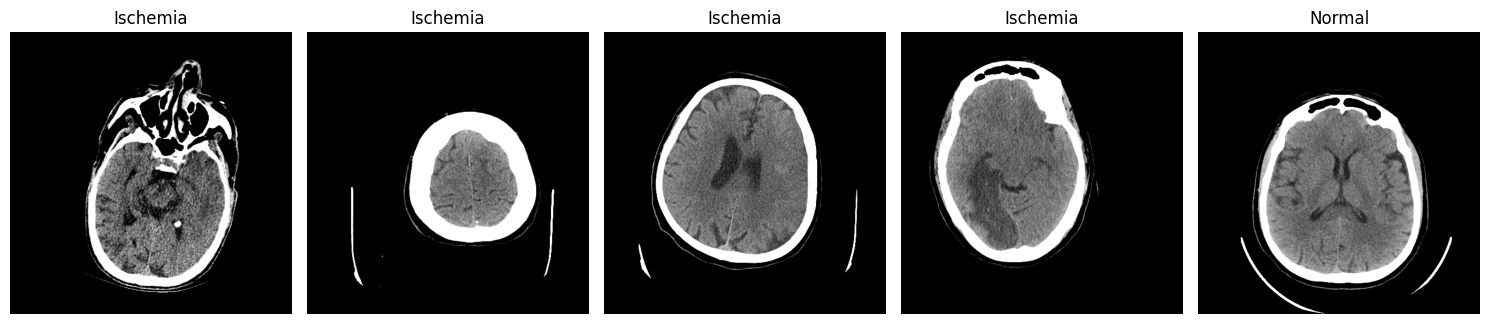

In [22]:
# Show 5 sample images
plt.figure(figsize=(15, 5))
for i in range(5):
    idx = random.randint(0, len(image_paths) - 1)
    img = Image.open(image_paths[idx])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.convert("L"), cmap='gray')  # Grayscale
    plt.title(labels[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()


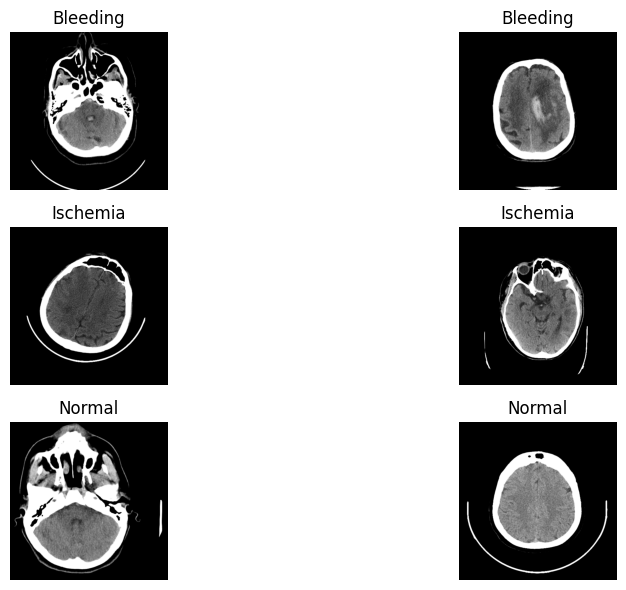

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import random

#  Your dataset path
DATASET_DIR = '/content/brain_ct_dataset/Brain-Stroke-CT-DatasetSplit/train'
classes = ['Bleeding', 'Ischemia', 'Normal']

plt.figure(figsize=(12, 6))

img_idx = 1
for label in classes:
    folder = os.path.join(DATASET_DIR, label)
    images = glob.glob(os.path.join(folder, '*.png'))

    # Select 2 random images from this class
    selected = random.sample(images, 2)

    for img_path in selected:
        img = Image.open(img_path)
        plt.subplot(3, 2, img_idx)
        plt.imshow(img.convert("L"), cmap='gray')
        plt.title(label)
        plt.axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()


In [24]:
from PIL import UnidentifiedImageError

bad_images = []

for class_name in classes:
    folder = os.path.join(DATASET_DIR, class_name)
    for path in glob.glob(os.path.join(folder, '*.png')):
        try:
            img = Image.open(path)
            img.verify()  # Check if image is corrupt
        except (UnidentifiedImageError, IOError, SyntaxError):
            print(f" Bad image: {path}")
            bad_images.append(path)

print(f"\n Total bad/corrupt images: {len(bad_images)}")



 Total bad/corrupt images: 0


In [25]:
from collections import defaultdict

class_counts = defaultdict(int)

for class_name in classes:
    folder = os.path.join(DATASET_DIR, class_name)
    count = len(glob.glob(os.path.join(folder, '*.png')))
    class_counts[class_name] = count

print("\n Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")



 Class Distribution:
Bleeding: 874 images
Ischemia: 904 images
Normal: 3541 images


In [26]:
import os
import glob
from PIL import Image
import pandas as pd

# INPUT dataset structure
INPUT_DIR = '/content/brain_ct_dataset/Brain-Stroke-CT-DatasetSplit/train'
CLASSES = ['Bleeding', 'Ischemia', 'Normal']

# OUTPUT structure
OUTPUT_DIR = '/content/processed_dataset'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Image size for BLIP-2 / ViLT
TARGET_SIZE = (224, 224)

# Collect info for CSV
data = []

for label in CLASSES:
    input_folder = os.path.join(INPUT_DIR, label)
    output_folder = os.path.join(OUTPUT_DIR, label)
    os.makedirs(output_folder, exist_ok=True)

    img_paths = glob.glob(os.path.join(input_folder, '*.png'))

    for i, img_path in enumerate(img_paths):
        try:
            img = Image.open(img_path).convert("L")  # Grayscale
            img = img.resize(TARGET_SIZE)

            # Save with new name
            filename = f"{label}_{i:05d}.png"
            save_path = os.path.join(output_folder, filename)
            img.save(save_path)

            # Append to CSV list
            data.append({'image_path': save_path, 'label': label})
        except Exception as e:
            print(f" Error processing {img_path}: {e}")

print(f" Done resizing and saving {len(data)} images.")


 Done resizing and saving 5319 images.


In [27]:
# Save metadata to CSV
df = pd.DataFrame(data)
csv_path = '/content/processed_dataset_labels.csv'
df.to_csv(csv_path, index=False)

print(f" CSV saved to: {csv_path}")
df.head()


 CSV saved to: /content/processed_dataset_labels.csv


,image_path,label
0,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding
1,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding
2,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding
3,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding
4,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding


In [28]:
import pandas as pd
import os

df = pd.read_csv('/content/processed_dataset_labels.csv')

# Count actual images
actual_image_count = sum([len(files) for _, _, files in os.walk('/content/processed_dataset')])
print(f" CSV rows: {len(df)}")
print(f" Actual PNG files: {actual_image_count}")


 CSV rows: 5319
 Actual PNG files: 5319


In [29]:
from PIL import Image
from tqdm import tqdm

bad_paths = []

for path in tqdm(df['image_path']):
    if not os.path.exists(path):
        bad_paths.append(path)
        continue
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_paths.append(path)

print(f" Total invalid or missing images: {len(bad_paths)}")


100%|██████████| 5319/5319 [00:00<00:00, 17778.35it/s]

 Total invalid or missing images: 0


In [30]:
print(" Class distribution in CSV:")
print(df['label'].value_counts())


 Class distribution in CSV:
label
Normal      3541
Ischemia     904
Bleeding     874
Name: count, dtype: int64


In [31]:
import random

# Define regions for variation
regions = [
    "left parietal lobe", "right temporal region", "frontal cortex",
    "left hemisphere", "basal ganglia", "posterior fossa", "occipital lobe"
]

# Define template per class
def generate_report(label):
    region = random.choice(regions)
    if label == "Bleeding":
        return f"CT scan shows evidence of intracranial bleeding localized to the {region}."
    elif label == "Ischemia":
        return f"Findings are consistent with an ischemic stroke affecting the {region}."
    elif label == "Normal":
        return "No acute intracranial abnormality. Brain parenchyma appears normal."
    else:
        return "Unknown finding."

# Load CSV
df = pd.read_csv('/content/processed_dataset_labels.csv')

# Apply synthetic report generation
df['report'] = df['label'].apply(generate_report)

# Save updated CSV
final_csv_path = '/content/final_dataset_with_reports.csv'
df.to_csv(final_csv_path, index=False)

print(f" Final dataset with reports saved: {final_csv_path}")
df.head()


 Final dataset with reports saved: /content/final_dataset_with_reports.csv


,image_path,label,report
0,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding,CT scan shows evidence of intracranial bleedin...
1,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding,CT scan shows evidence of intracranial bleedin...
2,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding,CT scan shows evidence of intracranial bleedin...
3,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding,CT scan shows evidence of intracranial bleedin...
4,/content/processed_dataset/Bleeding/Bleeding_0...,Bleeding,CT scan shows evidence of intracranial bleedin...


In [32]:
import pandas as pd

# Load the final dataset CSV
df = pd.read_csv('/content/final_dataset_with_reports.csv')

# Preview 5 random samples
sample_df = df.sample(5, random_state=42)
for idx, row in sample_df.iterrows():
    print(f" Image Path: {row['image_path']}")
    print(f" Label     : {row['label']}")
    print(f" Report    : {row['report']}")
    print("-" * 60)


 Image Path: /content/processed_dataset/Normal/Normal_00098.png
 Label     : Normal
 Report    : No acute intracranial abnormality. Brain parenchyma appears normal.
------------------------------------------------------------
 Image Path: /content/processed_dataset/Normal/Normal_03255.png
 Label     : Normal
 Report    : No acute intracranial abnormality. Brain parenchyma appears normal.
------------------------------------------------------------
 Image Path: /content/processed_dataset/Normal/Normal_01973.png
 Label     : Normal
 Report    : No acute intracranial abnormality. Brain parenchyma appears normal.
------------------------------------------------------------
 Image Path: /content/processed_dataset/Normal/Normal_00357.png
 Label     : Normal
 Report    : No acute intracranial abnormality. Brain parenchyma appears normal.
------------------------------------------------------------
 Image Path: /content/processed_dataset/Bleeding/Bleeding_00555.png
 Label     : Bleeding
 Repor

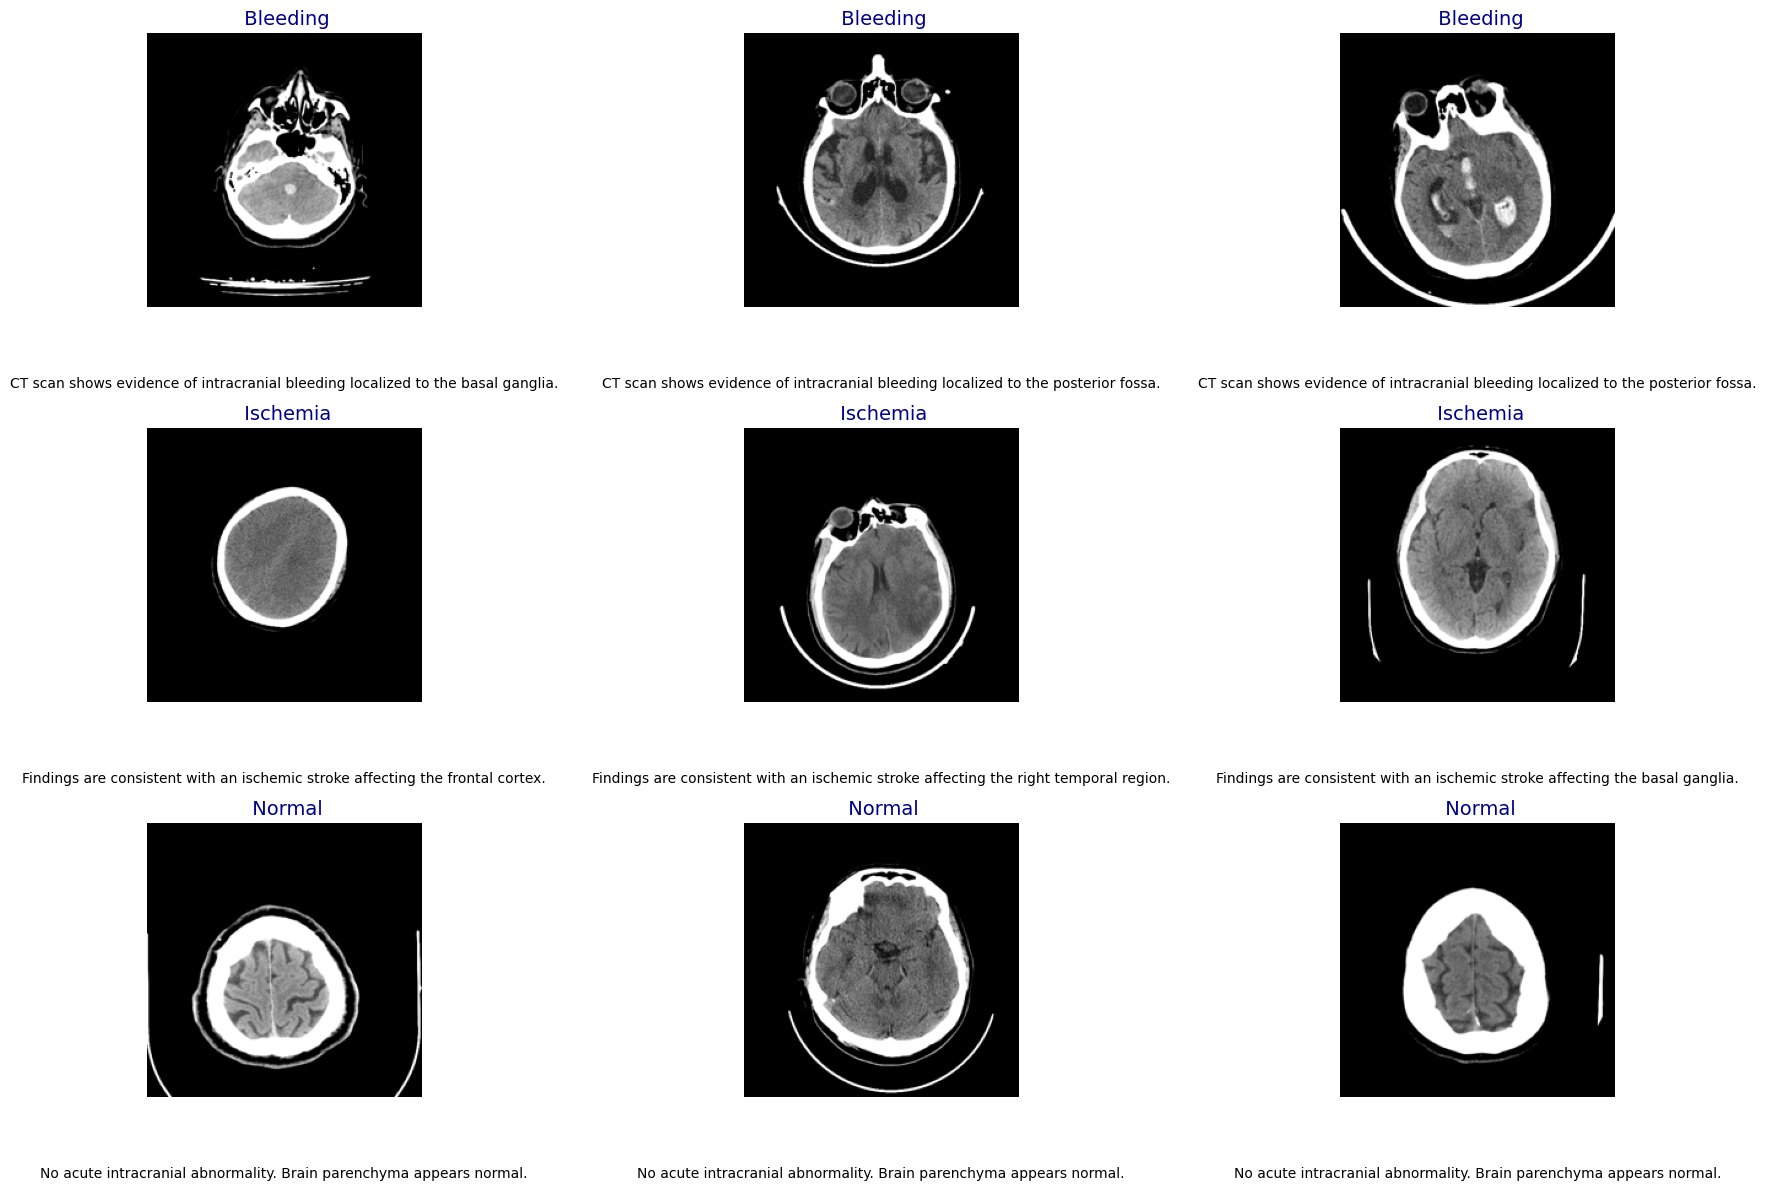

In [35]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Load the final dataset CSV
df = pd.read_csv('/content/final_dataset_with_reports.csv')

# Set classes
classes = ['Bleeding', 'Ischemia', 'Normal']

# Sample 3 images per class
samples = pd.concat([
    df[df['label'] == cls].sample(3, random_state=42) for cls in classes
]).reset_index(drop=True)

# Plot 9 images
plt.figure(figsize=(18, 12))

for i in range(len(samples)):
    row = samples.iloc[i]
    img = Image.open(row['image_path'])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.convert("L"), cmap='gray')
    plt.axis('off')
    plt.title(f" {row['label']}", fontsize=14, color='darkblue')

    # Add report below image
    plt.text(
        0.5, -0.25, row['report'],
        fontsize=10,
        ha='center',
        va='top',
        wrap=True,
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.show()


In [39]:
# Save CSV to Google Drive (optional)
!cp /content/final_dataset_with_reports.csv /content/drive/MyDrive/final_dataset_with_reports.csv


In [40]:
# Save the resized dataset folder to Google Drive
!cp -r /content/processed_dataset /content/drive/MyDrive/processed_dataset


In [1]:
!pip install -U transformers accelerate datasets torchvision


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Reload CSV
df = pd.read_csv('/content/drive/MyDrive/final_dataset_with_reports.csv')

# Optional: copy images back to local disk if needed
!cp -r /content/drive/MyDrive/processed_dataset /content/processed_dataset


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
GPU name: Tesla T4


In [3]:
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load processor and model
processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl", torch_dtype=torch.float16
).to(device)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/5.81G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [5]:
df = pd.read_csv('/content/drive/MyDrive/final_dataset_with_reports.csv')  # Or wherever you saved it


In [6]:
class CTReportDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.data = dataframe
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        report = row['report']

        inputs = self.processor(
            images=image,
            text=report,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs['labels'] = inputs['input_ids'].clone()  # for training

        return inputs


In [7]:
dataset = CTReportDataset(df, processor)
loader = DataLoader(dataset, batch_size=1, shuffle=True)


In [9]:
!pip install -U transformers


In [11]:
import transformers
print(transformers.__version__)


4.54.1


In [13]:
import torch
from tqdm import tqdm
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from torch.utils.data import DataLoader
from PIL import Image
import pandas as pd
import os


In [17]:
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b")
device = torch.device("cpu")
model.to(device)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

In [19]:
class CTReportDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, processor):
        self.data = dataframe
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        report = row['report']

        inputs = self.processor(
            images=image,
            text=report,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128
        )

        # Remove unnecessary fields
        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": inputs["input_ids"].squeeze(0)
        }


In [21]:
class CTReportDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, processor):
        self.data = dataframe
        self.processor = processor
        self.prompt = "Describe this medical image."

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        report = row['report']

        # Input = prompt, Label = report
        inputs = self.processor(
            images=image,
            text=self.prompt,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128
        )

        targets = self.processor.tokenizer(
            report,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=128
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": targets["input_ids"].squeeze(0)
        }


In [ ]:
from torch.amp import autocast, GradScaler
from tqdm import tqdm

train_loader = DataLoader(dataset, batch_size=1, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scaler = GradScaler()

model.train()
epochs = 3

for epoch in range(epochs):
    print(f"\n Epoch {epoch+1}/{epochs}")
    running_loss = 0.0
    correct_tokens = 0
    total_tokens = 0

    progress = tqdm(train_loader, desc="Training")

    for batch in progress:
        pixel_values = batch['pixel_values'].to(device, dtype=torch.float16)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        with autocast("cuda"):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

        # Calculate token-wise accuracy
        predictions = torch.argmax(logits, dim=-1)
        mask = labels != -100  # Ignore padding tokens
        correct_tokens += (predictions == labels).masked_select(mask).sum().item()
        total_tokens += mask.sum().item()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_tokens / total_tokens * 100
    print(f" Epoch {epoch+1} finished — Loss: {avg_loss:.4f} | Token Accuracy: {accuracy:.2f}%")



 Epoch 1/3


Training:   0%|          | 0/5319 [00:00<?, ?it/s]

In [ ]:
from torch.amp import autocast, GradScaler
from tqdm import tqdm

train_loader = DataLoader(dataset, batch_size=1, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scaler = GradScaler()

model.train()
epochs = 3

for epoch in range(epochs):
    print(f"\n Epoch {epoch+1}/{epochs}")
    running_loss = 0.0
    progress = tqdm(train_loader, desc="Training")

    for batch in progress:
        pixel_values = batch['pixel_values'].to(device, dtype=torch.float16)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        with autocast("cuda"):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    print(f" Epoch {epoch+1} completed — Avg Loss: {avg_loss:.4f}")
